<a href="https://colab.research.google.com/github/rarhin711/schnet_1/blob/main/SchNet_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!git clone https://github.com/atomistic-machine-learning/schnetpack.git

fatal: destination path 'schnetpack' already exists and is not an empty directory.


In [30]:
!pip -q install --force-reinstall "numpy==2.0.2" "pillow==11.3.0" "ase==3.26.0"

In [31]:
!pip -q install "schnetpack==2.2.0"

In [32]:
import os
import numpy as np
import torch
import torchmetrics
import pytorch_lightning as pl
import matplotlib.pyplot as plt

import schnetpack as spk
import schnetpack.transform as trn
from schnetpack.datasets import QM9
from ase import Atoms

In [33]:
workdir = "/content/schnetpack_run"
os.makedirs(workdir, exist_ok=True)

qm9_db = os.path.join(workdir, "qm9.db")
qm9_split = os.path.join(workdir, "qm9_split.npz")

In [46]:
qm9data = QM9(
    datapath=qm9_db,
    batch_size=64,
    num_train=100000,
    num_val=10000,
    split_file=qm9_split,
    load_properties=["energy_U0", "dipole_moment"],
    transforms=[
        trn.ASENeighborList(cutoff=5.0),
        trn.CastTo32(),
    ],
    num_workers=2,
    pin_memory=True,
)

qm9data.prepare_data()
qm9data.setup()

train_loader = qm9data.train_dataloader()
val_loader = qm9data.val_dataloader()
test_loader = qm9data.test_dataloader()

batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['_idx', 'energy_U0', 'dipole_moment', '_n_atoms', '_atomic_numbers', '_positions', '_cell', '_pbc', '_idx_i_local', '_idx_j_local', '_offsets', '_idx_m', '_idx_i', '_idx_j'])


In [55]:
#new
cutoff = 5.0
n_atom_basis = 128

pairwise_distance = spk.atomistic.PairwiseDistances()
radial_basis = spk.nn.GaussianRBF(n_rbf=20, cutoff=cutoff)

schnet = spk.representation.SchNet(
    n_atom_basis=n_atom_basis,
    n_interactions=3,
    radial_basis=radial_basis,
    cutoff_fn=spk.nn.CosineCutoff(cutoff),
)

pred_energy = spk.atomistic.Atomwise(
    n_in=n_atom_basis,
    output_key="energy_U0",
)

pred_dipole = spk.atomistic.DipoleMoment(
    n_in=n_atom_basis,
)

qm9_model = spk.model.NeuralNetworkPotential(
    representation=schnet,
    input_modules=[pairwise_distance],
    output_modules=[pred_energy, pred_dipole],
    postprocessors=[trn.CastTo64()],
)

In [59]:
cutoff = 5.0
n_atom_basis = 128

pairwise_distance = spk.atomistic.PairwiseDistances()
radial_basis = spk.nn.GaussianRBF(n_rbf=20, cutoff=cutoff)

schnet = spk.representation.SchNet(
    n_atom_basis=n_atom_basis,
    n_interactions=3,
    radial_basis=radial_basis,
    cutoff_fn=spk.nn.CosineCutoff(cutoff),
)

pred_energy = spk.atomistic.Atomwise(
    n_in=n_atom_basis,
    output_key="energy_U0",
)

pred_dipole = spk.atomistic.Atomwise(
    n_in=n_atom_basis,
    output_key="dipole_moment",
)

qm9_model = spk.model.NeuralNetworkPotential(
    representation=schnet,
    input_modules=[pairwise_distance],
    output_modules=[pred_energy, pred_dipole],
    postprocessors=[trn.CastTo64()],
)

In [60]:
qm9_outputs = [
    spk.task.ModelOutput(
        name="energy_U0",
        loss_fn=torch.nn.MSELoss(),
        loss_weight=1.0,
        metrics={"MAE": torchmetrics.MeanAbsoluteError()},
    ),
    spk.task.ModelOutput(
        name="dipole_moment",
        loss_fn=torch.nn.MSELoss(),
        loss_weight=1.0,
        metrics={"MAE": torchmetrics.MeanAbsoluteError()},
    ),
]

qm9_task = spk.task.AtomisticTask(
    model=qm9_model,
    outputs=qm9_outputs,
    optimizer_cls=torch.optim.AdamW,
    optimizer_args={"lr": 1e-4},
)

In [61]:
qm9_logdir = os.path.join(workdir, "lightning_qm9")

qm9_callbacks = [
    spk.train.ModelCheckpoint(
        model_path=os.path.join(workdir, "best_qm9_model"),
        save_top_k=1,
        monitor="val_loss",
    )
]

qm9_trainer = pl.Trainer(
    default_root_dir=qm9_logdir,
    max_epochs=50,
    callbacks=qm9_callbacks,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
)

qm9_trainer.fit(qm9_task, datamodule=qm9data)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ NeuralNetworkPotential │  235 K │ train │     0 │
│ 1 │ outputs │ ModuleList             │      0 │ train │     0 │
└───┴─────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [62]:
import os
from schnetpack.utils.compatibility import load_model

best_qm9_model = load_model(
    os.path.join(workdir, "best_qm9_model"),
    device="cuda" if torch.cuda.is_available() else "cpu",
)

best_qm9_model.eval()

NeuralNetworkPotential(
  (postprocessors): ModuleList(
    (0): CastTo64()
  )
  (representation): SchNet(
    (radial_basis): GaussianRBF()
    (cutoff_fn): CosineCutoff()
    (embedding): Embedding(100, 128)
    (electronic_embeddings): ModuleList()
    (interactions): ModuleList(
      (0-2): 3 x SchNetInteraction(
        (in2f): Dense(
          in_features=128, out_features=128, bias=False
          (activation): Identity()
        )
        (f2out): Sequential(
          (0): Dense(in_features=128, out_features=128, bias=True)
          (1): Dense(
            in_features=128, out_features=128, bias=True
            (activation): Identity()
          )
        )
        (filter_network): Sequential(
          (0): Dense(in_features=20, out_features=128, bias=True)
          (1): Dense(
            in_features=128, out_features=128, bias=True
            (activation): Identity()
          )
        )
      )
    )
  )
  (input_modules): ModuleList(
    (0): PairwiseDistances()
 

In [63]:
qm9_test_loader = qm9data.test_dataloader()
device = "cuda" if torch.cuda.is_available() else "cpu"

qm9_energy_true = []
qm9_energy_pred = []
qm9_mu_true = []
qm9_mu_pred = []

best_qm9_model.eval()

with torch.no_grad():
    for batch in qm9_test_loader:
        batch = {
            k: v.to(device) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

        # save ground truth BEFORE model modifies batch
        true_energy = batch["energy_U0"].detach().cpu().numpy().copy()
        true_mu = batch["dipole_moment"].detach().cpu().numpy().copy()

        pred = best_qm9_model(batch)

        pred_energy = pred["energy_U0"].detach().cpu().numpy().copy()
        pred_mu = pred["dipole_moment"].detach().cpu().numpy().copy()

        qm9_energy_true.append(true_energy)
        qm9_energy_pred.append(pred_energy)

        qm9_mu_true.append(true_mu)
        qm9_mu_pred.append(pred_mu)

qm9_energy_true = np.concatenate(qm9_energy_true, axis=0)
qm9_energy_pred = np.concatenate(qm9_energy_pred, axis=0)

qm9_mu_true = np.concatenate(qm9_mu_true, axis=0)
qm9_mu_pred = np.concatenate(qm9_mu_pred, axis=0)

print("QM9 prediction complete.")
print("Energy MAE quick check:", np.mean(np.abs(qm9_energy_true - qm9_energy_pred)))
print("Dipole MAE quick check:", np.mean(np.abs(qm9_mu_true - qm9_mu_pred)))

QM9 prediction complete.
Energy MAE quick check: 0.2759672374402528
Dipole MAE quick check: 0.4338262157884741


In [64]:
print("Energy true sample:", qm9_energy_true[:5])
print("Energy pred sample:", qm9_energy_pred[:5])

print("Dipole true sample:", qm9_mu_true[:5])
print("Dipole pred sample:", qm9_mu_pred[:5])

print("Shapes:")
print(qm9_energy_true.shape, qm9_energy_pred.shape)
print(qm9_mu_true.shape, qm9_mu_pred.shape)

Energy true sample: [-461.97678 -421.8626  -422.9652  -365.0034  -401.98032]
Energy pred sample: [-462.25888062 -421.75595093 -422.96353149 -365.17941284 -402.1295166 ]
Dipole true sample: [5.4969 3.6386 2.3333 1.7716 3.1797]
Dipole pred sample: [4.74971008 3.46597576 2.30366874 1.74180365 3.20565081]
Shapes:
(13885,) (13885,)
(13885,) (13885,)


In [65]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    return mae, rmse

In [67]:
import matplotlib.pyplot as plt
import numpy as np

def plot_parity(y_true, y_pred, title):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.5)

    # perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid()
    plt.show()

0.2759672374402528 0.38521781478153566
0.4338262157884741 0.6054216862361049


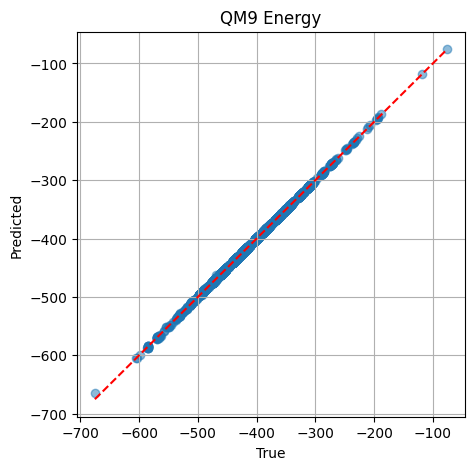

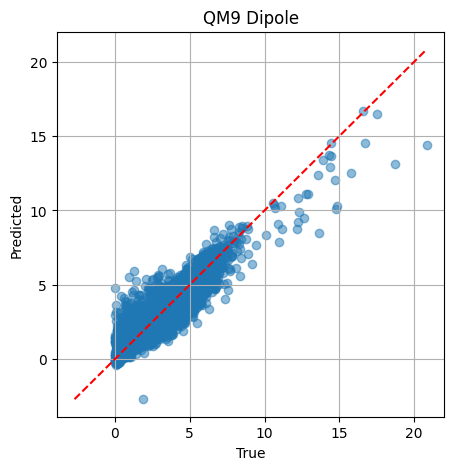

In [68]:
mae_E, rmse_E = regression_metrics(qm9_energy_true, qm9_energy_pred)
mae_mu, rmse_mu = regression_metrics(qm9_mu_true, qm9_mu_pred)

print(mae_E, rmse_E)
print(mae_mu, rmse_mu)

plot_parity(qm9_energy_true, qm9_energy_pred, "QM9 Energy")
plot_parity(qm9_mu_true, qm9_mu_pred, "QM9 Dipole")

In [116]:
import numpy as np

data = np.load("/content/QeMFi_acrolein.npz", allow_pickle=True)

print(data.files)
# expected keys include:
# ['ID','R','Z','CONF','SCF','EV','TrDP','fosc','DPe','DPn','RCo','DPRo']

['ID', 'R', 'Z', 'CONF', 'SCF', 'EV', 'TrDP', 'fosc', 'DPe', 'DPn', 'RCo', 'DPRo', 't']


In [119]:
import numpy as np
import os
import schnetpack as spk
from ase import Atoms
data = np.load("/content/QeMFi_acrolein.npz", allow_pickle=True)
print(data.files)
FIDELITY_INDEX = 4   # def2-TZVP
N_STATES = 3
Z = data["Z"]                                 # (n_atoms,)
R = data["R"]                                 # (15000, n_atoms, 3)
E3_cm = data["EV"][:, FIDELITY_INDEX, :N_STATES]     # (15000, 3)
f3 = data["fosc"][:, FIDELITY_INDEX, :N_STATES]      # (15000, 3)
CM_TO_EV = 1.0 / 8065.54429
E3 = E3_cm * CM_TO_EV
db_path = "qmefi_data/qemfi_acrolein_3state.db"
EXC_KEY = "excitation_energies"
OSC_KEY = "oscillator_strengths"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(db_path), exist_ok=True)

# remove old db if it exists
if os.path.exists(db_path):
    os.remove(db_path)
# define units for the properties
property_unit_dict = {
    EXC_KEY: "eV",
    OSC_KEY: "1",   # dimensionless
}
# create SchNetPack ASEAtomsData database
dataset = spk.data.ASEAtomsData.create(
    datapath=db_path,
    distance_unit="Ang",
    property_unit_dict=property_unit_dict,
)
# build atoms list and property list
atoms_list = []
property_list = []
for i in range(len(R)):
    atoms = Atoms(numbers=Z, positions=R[i])
    props = {
        EXC_KEY: E3[i].astype(np.float32)[None, :],
        OSC_KEY: f3[i].astype(np.float32)[None, :],
    }
    atoms_list.append(atoms)
    property_list.append(props)
# add all systems to the dataset
dataset.add_systems(property_list=property_list, atoms_list=atoms_list)
...

['ID', 'R', 'Z', 'CONF', 'SCF', 'EV', 'TrDP', 'fosc', 'DPe', 'DPn', 'RCo', 'DPRo', 't']


Ellipsis

In [120]:
FIDELITY_INDEX = 4   # def2-TZVP
N_STATES = 3

Z = data["Z"]                                 # (n_atoms,)
R = data["R"]                                 # (15000, n_atoms, 3)
E3_cm = data["EV"][:, FIDELITY_INDEX, :N_STATES]     # (15000, 3)
f3 = data["fosc"][:, FIDELITY_INDEX, :N_STATES]      # (15000, 3)

print("Z shape   :", Z.shape)
print("R shape   :", R.shape)
print("E3_cm shape:", E3_cm.shape)
print("f3 shape  :", f3.shape)

Z shape   : (8,)
R shape   : (15000, 8, 3)
E3_cm shape: (15000, 3)
f3 shape  : (15000, 3)


In [121]:
CM_TO_EV = 1.0 / 8065.54429
E3 = E3_cm * CM_TO_EV

print("Example first geometry:")
print("E (cm^-1):", E3_cm[0])
print("E (eV)   :", E3[0])
print("f        :", f3[0])

Example first geometry:
E (cm^-1): [25870.8 46391.1 52706.2]
E (eV)   : [3.20757026 5.7517631  6.53473567]
f        : [0.00034694 0.27408294 0.14082876]


In [122]:
import os
import numpy as np
import schnetpack as spk
from ase import Atoms

db_path = "qmefi_data/qemfi_acrolein_3state.db"

EXC_KEY = "excitation_energies"
OSC_KEY = "oscillator_strengths"

# remove old db if it exists
if os.path.exists(db_path):
    os.remove(db_path)

# define units for the properties
property_unit_dict = {
    EXC_KEY: "eV",
    OSC_KEY: "1",   # dimensionless
}

# create SchNetPack ASEAtomsData database
dataset = spk.data.ASEAtomsData.create(
    datapath=db_path,
    distance_unit="Ang",
    property_unit_dict=property_unit_dict,
)

# build atoms list and property list
atoms_list = []
property_list = []

for i in range(len(R)):
    atoms = Atoms(numbers=Z, positions=R[i])
    props = {
        EXC_KEY: E3[i].astype(np.float32)[None, :],
        OSC_KEY: f3[i].astype(np.float32)[None, :],
    }

    atoms_list.append(atoms)
    property_list.append(props)

# add all systems to the dataset
dataset.add_systems(property_list=property_list, atoms_list=atoms_list)

print(f"Saved SchNetPack DB to: {db_path}")
print("Available properties:", dataset.available_properties)

Saved SchNetPack DB to: qmefi_data/qemfi_acrolein_3state.db
Available properties: ['excitation_energies', 'oscillator_strengths']


In [123]:
from ase.db import connect

with connect(db_path) as db:
    print("Rows in DB:", db.count())

Rows in DB: 15000


In [124]:
import os

split_file = "qmefi_data/qemfi_acrolein_split.npz"
if os.path.exists(split_file):
    os.remove(split_file)

In [125]:
import schnetpack as spk
import schnetpack.transform as trn

split_file = "qmefi_data/qemfi_acrolein_split.npz"

datamodule = spk.data.AtomsDataModule(
    datapath=db_path,
    batch_size=64,
    num_train=9000,
    num_val=1500,
    transforms=[
        trn.ASENeighborList(cutoff=5.0),
        trn.CastTo32(),
    ],
    split_file=split_file,
    load_properties=[EXC_KEY, OSC_KEY],
    num_workers=2,
    pin_memory=True,
)

datamodule.prepare_data()
datamodule.setup()
train_loader = datamodule.train_dataloader()
val_loader = datamodule.val_dataloader()
test_loader = datamodule.test_dataloader()

In [126]:
full_dataset = spk.data.ASEAtomsData(datapath=db_path)
print("Properties:", full_dataset.available_properties)
print("Length:", len(full_dataset))

Properties: ['excitation_energies', 'oscillator_strengths']
Length: 15000


In [127]:
print("Train size:", len(datamodule.train_dataset))
print("Val size  :", len(datamodule.val_dataset))
print("Test size :", len(datamodule.test_dataset))

batch = next(iter(datamodule.train_dataloader()))

print(batch.keys())
print("excitation_energies shape:", batch["excitation_energies"].shape)
print("oscillator_strengths shape:", batch["oscillator_strengths"].shape)

print("first excitation target:", batch["excitation_energies"][0])
print("first oscillator target:", batch["oscillator_strengths"][0])

Train size: 9000
Val size  : 1500
Test size : 4500
dict_keys(['_idx', 'excitation_energies', 'oscillator_strengths', '_n_atoms', '_atomic_numbers', '_positions', '_cell', '_pbc', '_idx_i_local', '_idx_j_local', '_offsets', '_idx_m', '_idx_i', '_idx_j'])
excitation_energies shape: torch.Size([64, 3])
oscillator_strengths shape: torch.Size([64, 3])
first excitation target: tensor([3.6747, 6.5817, 6.9385])
first oscillator target: tensor([3.1845e-04, 4.1323e-01, 7.8670e-02])


In [128]:
import torch
import torchmetrics
import pytorch_lightning as pl
import schnetpack as spk
import schnetpack.transform as trn

EXC_KEY = "excitation_energies"
OSC_KEY = "oscillator_strengths"

cutoff = 5.0
n_atom_basis = 128

pairwise_distance = spk.atomistic.PairwiseDistances()
radial_basis = spk.nn.GaussianRBF(n_rbf=20, cutoff=cutoff)

schnet = spk.representation.SchNet(
    n_atom_basis=n_atom_basis,
    n_interactions=3,
    radial_basis=radial_basis,
    cutoff_fn=spk.nn.CosineCutoff(cutoff),
)

pred_exc = spk.atomistic.Atomwise(
    n_in=n_atom_basis,
    n_out=3,
    output_key=EXC_KEY,
)

pred_osc = spk.atomistic.Atomwise(
    n_in=n_atom_basis,
    n_out=3,
    output_key=OSC_KEY,
)

model = spk.model.NeuralNetworkPotential(
    representation=schnet,
    input_modules=[pairwise_distance],
    output_modules=[pred_exc, pred_osc],
    postprocessors=[trn.CastTo64()],
)

out_exc = spk.task.ModelOutput(
    name=EXC_KEY,
    loss_fn=torch.nn.MSELoss(),
    loss_weight=1.0,
    metrics={"MAE": torchmetrics.MeanAbsoluteError()},
)

out_osc = spk.task.ModelOutput(
    name=OSC_KEY,
    loss_fn=torch.nn.MSELoss(),
    loss_weight=1.0,
    metrics={"MAE": torchmetrics.MeanAbsoluteError()},
)

task = spk.task.AtomisticTask(
    model=model,
    outputs=[out_exc, out_osc],
    optimizer_cls=torch.optim.AdamW,
    optimizer_args={"lr": 1e-4},
)

print("Model ready.")

Model ready.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


In [129]:
batch = next(iter(datamodule.train_dataloader()))

print("excitation_energies:", batch["excitation_energies"].shape)
print("oscillator_strengths:", batch["oscillator_strengths"].shape)

excitation_energies: torch.Size([64, 3])
oscillator_strengths: torch.Size([64, 3])


In [130]:
logdir = "qmefi_data/lightning_acrolein"

callbacks = [
    spk.train.ModelCheckpoint(
        model_path="qmefi_data/best_acrolein_model",
        save_top_k=1,
        monitor="val_loss",
    )
]

trainer = pl.Trainer(
    default_root_dir=logdir,
    max_epochs=20,
    callbacks=callbacks,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
)

trainer.fit(task, datamodule=datamodule)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ NeuralNetworkPotential │  235 K │ train │     0 │
│ 1 │ outputs │ ModuleList             │      0 │ train │     0 │
└───┴─────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 235 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 235 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:365: Skipping 'outputs' parameter because it is not possible to safely dump to YAML.


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


In [131]:
trainer.test(task, datamodule=datamodule)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric          ┃         DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ test_excitation_energies_MAE  │      0.11172977089881897      │
│           test_loss           │      0.02990923821926117      │
│ test_oscillator_strengths_MAE │      0.05457311496138573      │
└───────────────────────────────┴───────────────────────────────┘

[{'test_loss': 0.02990923821926117,
  'test_excitation_energies_MAE': 0.11172977089881897,
  'test_oscillator_strengths_MAE': 0.05457311496138573}]

In [132]:
import numpy as np
import torch

task.model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
task.model.to(device)

all_exc_pred = []
all_exc_true = []
all_osc_pred = []
all_osc_true = []

with torch.no_grad():
    for batch in datamodule.test_dataloader():
        batch = {k: v.to(device) if hasattr(v, "to") else v for k, v in batch.items()}
        pred = task.model(batch)

        all_exc_pred.append(pred[EXC_KEY].detach().cpu().numpy())
        all_exc_true.append(batch[EXC_KEY].detach().cpu().numpy())
        all_osc_pred.append(pred[OSC_KEY].detach().cpu().numpy())
        all_osc_true.append(batch[OSC_KEY].detach().cpu().numpy())

all_exc_pred = np.vstack(all_exc_pred)
all_exc_true = np.vstack(all_exc_true)
all_osc_pred = np.vstack(all_osc_pred)
all_osc_true = np.vstack(all_osc_true)

print(all_exc_pred.shape, all_exc_true.shape)
print(all_osc_pred.shape, all_osc_true.shape)

(4500, 3) (4500, 3)
(4500, 3) (4500, 3)


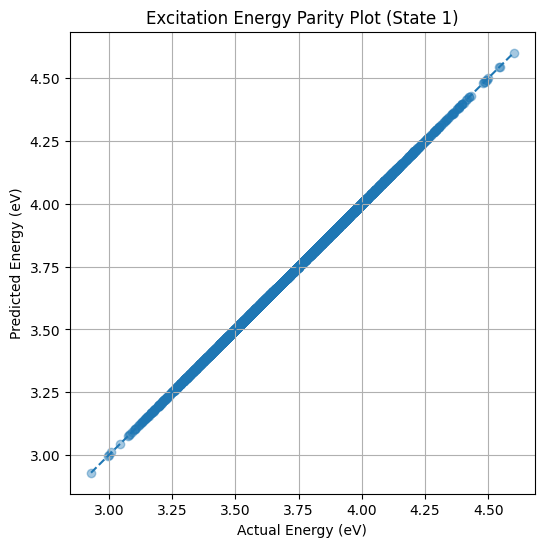

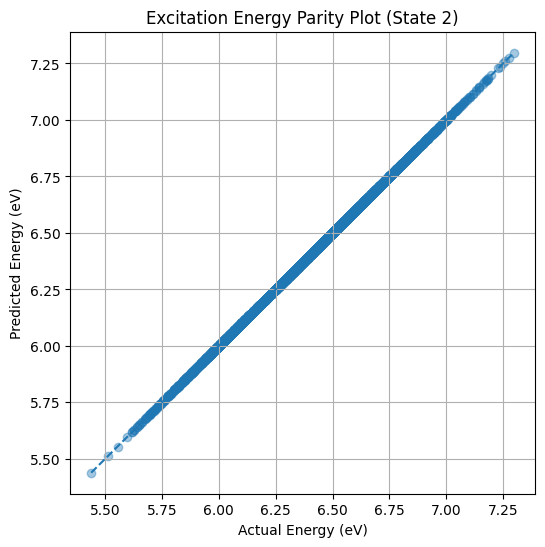

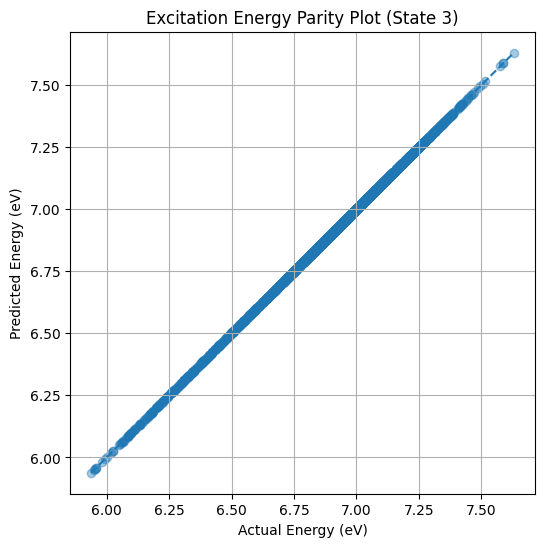

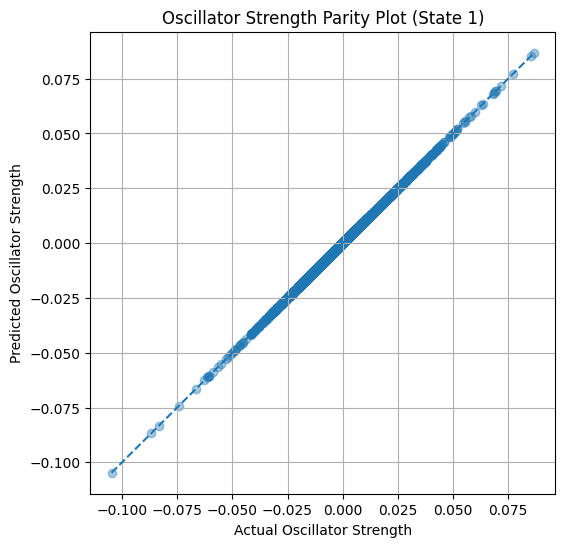

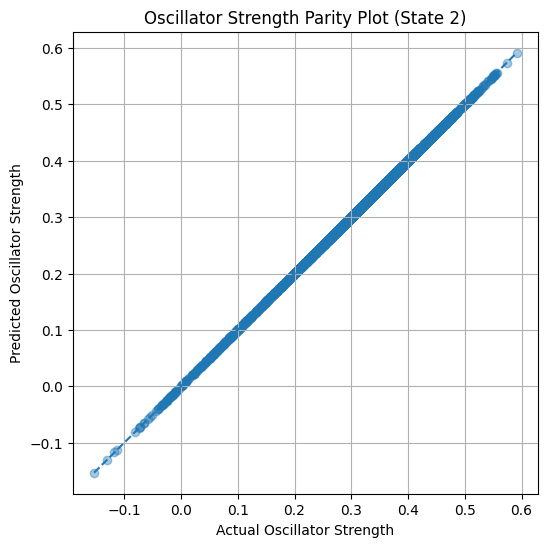

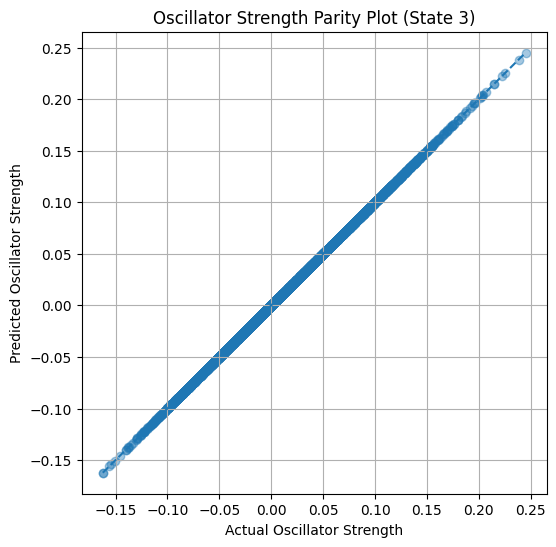

In [133]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title, xlabel, ylabel):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], "--")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

for i in range(3):
    parity_plot(
        all_exc_true[:, i],
        all_exc_pred[:, i],
        f"Excitation Energy Parity Plot (State {i+1})",
        "Actual Energy (eV)",
        "Predicted Energy (eV)"
    )

for i in range(3):
    parity_plot(
        all_osc_true[:, i],
        all_osc_pred[:, i],
        f"Oscillator Strength Parity Plot (State {i+1})",
        "Actual Oscillator Strength",
        "Predicted Oscillator Strength"
    )

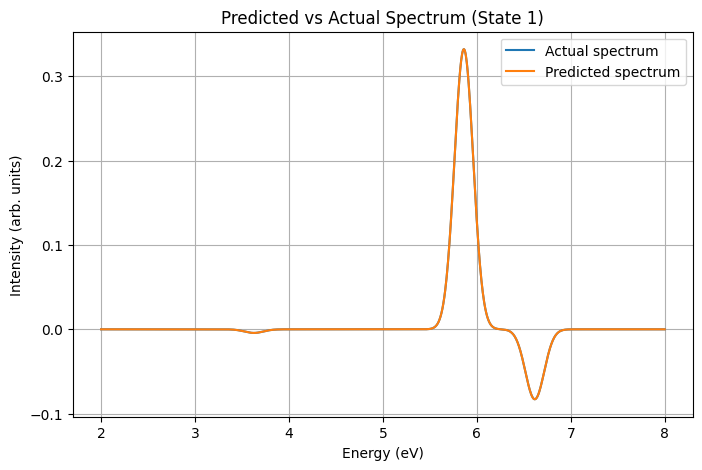

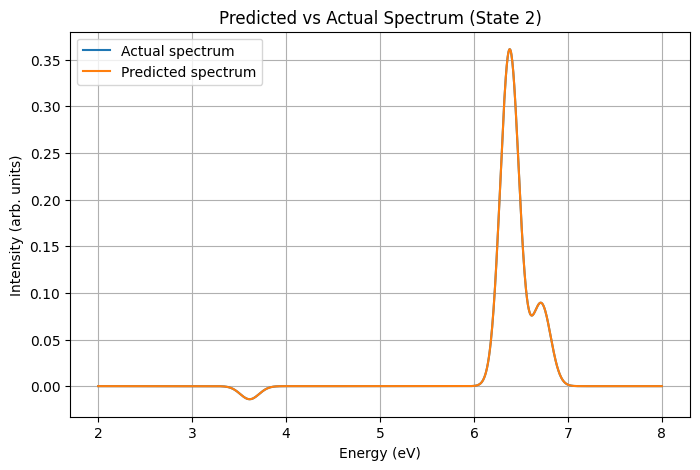

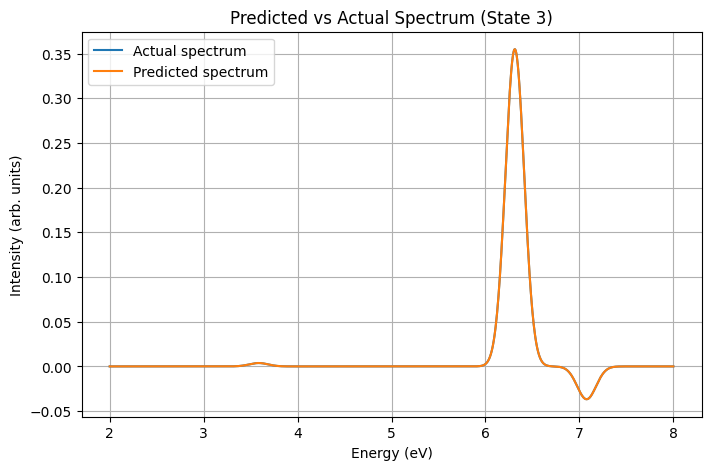

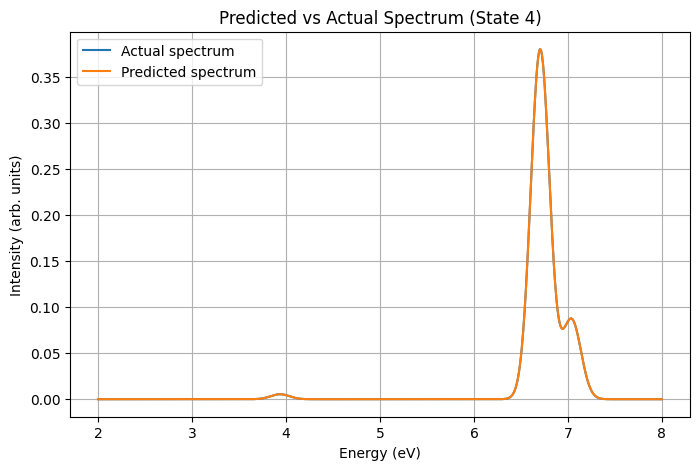

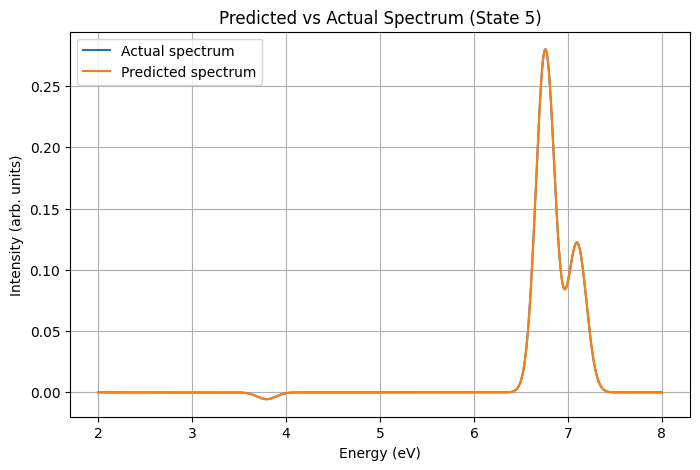

In [135]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_spectrum(energies, osc_strengths, grid, sigma=0.10):
    spec = np.zeros_like(grid)
    for E, f in zip(energies, osc_strengths):
        spec += f * np.exp(-0.5 * ((grid - E) / sigma) ** 2)
    return spec

energy_grid = np.linspace(2.0, 8.0, 1200)

for idx in range(5):
    E_true = all_exc_true[idx]
    E_pred = all_exc_pred[idx]
    f_true = all_osc_true[idx]
    f_pred = all_osc_pred[idx]

    spec_true = gaussian_spectrum(E_true, f_true, energy_grid, sigma=0.10)
    spec_pred = gaussian_spectrum(E_pred, f_pred, energy_grid, sigma=0.10)

    plt.figure(figsize=(8, 5))
    plt.plot(energy_grid, spec_true, label="Actual spectrum")
    plt.plot(energy_grid, spec_pred, label="Predicted spectrum")
    plt.xlabel("Energy (eV)")
    plt.ylabel("Intensity (arb. units)")
    plt.title(f"Predicted vs Actual Spectrum (State {idx+1})")
    plt.legend()
    plt.grid(True)
    plt.show()